In [1]:
import json
import time
from pathlib import Path
import pandas as pd
import numpy as np
import torch
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer,
    DataCollatorWithPadding,
)
from peft import LoraConfig, get_peft_model, TaskType
from datasets import Dataset
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# Paths
PROJECT_ROOT  = Path.home() / "icidea_llm_ids"
ARTIFACTS_DIR = PROJECT_ROOT / "artifacts"
CHECKPOINTS   = PROJECT_ROOT / "checkpoints"
CHECKPOINTS.mkdir(exist_ok=True)

# Device
device = torch.device("mps") if torch.backends.mps.is_available() else torch.device("cpu")
print(f"Device: {device}")

LABEL_MAP     = {0: "NORMAL", 1: "DOS", 2: "FUZZY", 3: "GEAR", 4: "RPM"}
LABEL_MAP_INV = {v: k for k, v in LABEL_MAP.items()}
NUM_LABELS    = 5
SEED          = 42
torch.manual_seed(SEED)
np.random.seed(SEED)

# Load benchmark
t0 = time.time()
benchmark = pd.read_parquet(ARTIFACTS_DIR / "section8_benchmark.parquet")
print(f"✓ Loaded benchmark: {len(benchmark):,} windows in {time.time()-t0:.2f}s")

# Split
train_df = benchmark[benchmark["split"].isin(["val", "reserve"])].reset_index(drop=True)
test_df  = benchmark[benchmark["split"] == "test"].reset_index(drop=True)
print(f"  Train (val+reserve): {len(train_df):,} windows")
print(f"  Test:                {len(test_df):,} windows")
print(f"\nTrain class distribution:")
print(train_df["label"].value_counts().sort_index().rename(LABEL_MAP).to_string())

Device: mps
✓ Loaded benchmark: 2,500 windows in 0.45s
  Train (val+reserve): 1,000 windows
  Test:                1,500 windows

Train class distribution:
label
NORMAL    200
DOS       200
FUZZY     200
GEAR      200
RPM       200


In [2]:
print("Loading SecureBERT with classification head...")
t0 = time.time()

tokenizer = AutoTokenizer.from_pretrained("ehsanaghaei/SecureBERT")
model = AutoModelForSequenceClassification.from_pretrained(
    "ehsanaghaei/SecureBERT",
    num_labels=NUM_LABELS,
    ignore_mismatched_sizes=True,
)

print(f"✓ Model loaded in {time.time()-t0:.1f}s")
print(f"  Total parameters: {sum(p.numel() for p in model.parameters())/1e6:.1f}M")

Loading SecureBERT with classification head...


/Users/deepakpatnaik/icidea_llm_ids/venv/lib/python3.11/site-packages/transformers/tokenization_utils_base.py:1601: FutureWarning: `clean_up_tokenization_spaces` was not set. It will be set to `True` by default. This behavior will be depracted in transformers v4.45, and will be then set to `False` by default. For more details check this issue: https://github.com/huggingface/transformers/issues/31884
  warnings.warn(
Some weights of RobertaForSequenceClassification were not initialized from the model checkpoint at ehsanaghaei/SecureBERT and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


✓ Model loaded in 4.0s
  Total parameters: 124.6M


In [3]:
lora_config = LoraConfig(
    task_type=TaskType.SEQ_CLS,
    r=8,                          # LoRA rank
    lora_alpha=16,                # scaling factor
    lora_dropout=0.1,
    target_modules=["query", "value"],  # which attention layers to adapt
    bias="none",
)

model = get_peft_model(model, lora_config)
model.print_trainable_parameters()

trainable params: 889,349 || all params: 125,538,826 || trainable%: 0.7084


In [4]:
def tokenize(examples):
    return tokenizer(
        examples["text"],
        truncation=True,
        max_length=512,
        padding="max_length",  # fixed length, no dynamic recompilation
    )

train_hf = Dataset.from_pandas(train_df[["text", "label"]])
test_hf  = Dataset.from_pandas(test_df[["text", "label"]])

train_tokenized = train_hf.map(tokenize, batched=True, desc="Tokenizing train")
test_tokenized  = test_hf.map(tokenize, batched=True, desc="Tokenizing test")

train_tokenized = train_tokenized.rename_column("label", "labels")
test_tokenized  = test_tokenized.rename_column("label", "labels")

train_tokenized.set_format("torch", columns=["input_ids", "attention_mask", "labels"])
test_tokenized.set_format("torch", columns=["input_ids", "attention_mask", "labels"])

print(f"✓ Tokenized: {len(train_tokenized)} train, {len(test_tokenized)} test")
print(f"  All sequences padded to 512 tokens (fixed length)")

Tokenizing train:   0%|          | 0/1000 [00:00<?, ? examples/s]

Tokenizing test:   0%|          | 0/1500 [00:00<?, ? examples/s]

✓ Tokenized: 1000 train, 1500 test
  All sequences padded to 512 tokens (fixed length)


In [5]:
from transformers import default_data_collator

training_args = TrainingArguments(
    output_dir=str(CHECKPOINTS / "securebert_can"),
    num_train_epochs=5,
    per_device_train_batch_size=4,    # reduced from 8
    per_device_eval_batch_size=8,
    learning_rate=2e-4,
    warmup_ratio=0.1,
    weight_decay=0.01,
    eval_strategy="epoch",            # updated from deprecated evaluation_strategy
    save_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model="eval_loss",
    logging_steps=10,
    seed=SEED,
    fp16=False,
    dataloader_num_workers=0,
    report_to="none",
)

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=-1)
    acc = (predictions == labels).mean()
    return {"accuracy": acc}

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_tokenized,
    eval_dataset=test_tokenized,
    data_collator=default_data_collator,  # no dynamic padding
    compute_metrics=compute_metrics,
)

print("✓ Trainer configured")
print(f"  Epochs:     {training_args.num_train_epochs}")
print(f"  Batch size: {training_args.per_device_train_batch_size}")
print(f"  Steps/epoch:{len(train_tokenized) // training_args.per_device_train_batch_size}")

✓ Trainer configured
  Epochs:     5
  Batch size: 4
  Steps/epoch:250


In [6]:
print("Starting fine-tuning...")
print("Expected time: 20-40 minutes on M2")
print()

t0 = time.time()
trainer.train()
elapsed = time.time() - t0

print(f"\n✓ Training complete in {elapsed/60:.1f} minutes")

Starting fine-tuning...
Expected time: 20-40 minutes on M2



  0%|          | 0/1250 [00:00<?, ?it/s]

{'loss': 1.6162, 'grad_norm': 3.8628756999969482, 'learning_rate': 1.6000000000000003e-05, 'epoch': 0.04}
{'loss': 1.6059, 'grad_norm': 1.044106125831604, 'learning_rate': 3.2000000000000005e-05, 'epoch': 0.08}
{'loss': 1.6216, 'grad_norm': 3.761380195617676, 'learning_rate': 4.8e-05, 'epoch': 0.12}
{'loss': 1.6031, 'grad_norm': 4.727094650268555, 'learning_rate': 6.400000000000001e-05, 'epoch': 0.16}
{'loss': 1.5905, 'grad_norm': 3.3609397411346436, 'learning_rate': 8e-05, 'epoch': 0.2}
{'loss': 1.5915, 'grad_norm': 0.8125550746917725, 'learning_rate': 9.6e-05, 'epoch': 0.24}
{'loss': 1.567, 'grad_norm': 5.158070087432861, 'learning_rate': 0.00011200000000000001, 'epoch': 0.28}
{'loss': 1.5747, 'grad_norm': 0.8393969535827637, 'learning_rate': 0.00012800000000000002, 'epoch': 0.32}
{'loss': 1.5477, 'grad_norm': 1.3717941045761108, 'learning_rate': 0.000144, 'epoch': 0.36}
{'loss': 1.489, 'grad_norm': 1.5231220722198486, 'learning_rate': 0.00016, 'epoch': 0.4}
{'loss': 1.0773, 'grad_no

  0%|          | 0/188 [00:00<?, ?it/s]

{'eval_loss': 0.0009104740456677973, 'eval_accuracy': 1.0, 'eval_runtime': 172.0548, 'eval_samples_per_second': 8.718, 'eval_steps_per_second': 1.093, 'epoch': 1.0}
{'loss': 0.003, 'grad_norm': 0.06700067222118378, 'learning_rate': 0.00017600000000000002, 'epoch': 1.04}
{'loss': 0.0059, 'grad_norm': 0.024140311405062675, 'learning_rate': 0.00017422222222222223, 'epoch': 1.08}
{'loss': 0.001, 'grad_norm': 0.00618657935410738, 'learning_rate': 0.00017244444444444444, 'epoch': 1.12}
{'loss': 0.0012, 'grad_norm': 0.058875806629657745, 'learning_rate': 0.00017066666666666668, 'epoch': 1.16}
{'loss': 0.0033, 'grad_norm': 0.38319894671440125, 'learning_rate': 0.00016888888888888889, 'epoch': 1.2}
{'loss': 0.002, 'grad_norm': 0.023950684815645218, 'learning_rate': 0.00016711111111111112, 'epoch': 1.24}
{'loss': 0.0014, 'grad_norm': 0.07180038094520569, 'learning_rate': 0.00016533333333333333, 'epoch': 1.28}
{'loss': 0.0025, 'grad_norm': 0.20505128800868988, 'learning_rate': 0.00016355555555555

...

{'eval_loss': 1.7228072465513833e-05, 'eval_accuracy': 1.0, 'eval_runtime': 157.3136, 'eval_samples_per_second': 9.535, 'eval_steps_per_second': 1.195, 'epoch': 3.0}
{'loss': 0.0001, 'grad_norm': 0.0014215590199455619, 'learning_rate': 8.711111111111112e-05, 'epoch': 3.04}
{'loss': 0.0002, 'grad_norm': 0.0075537292286753654, 'learning_rate': 8.533333333333334e-05, 'epoch': 3.08}
{'loss': 0.0003, 'grad_norm': 0.0017746806843206286, 'learning_rate': 8.355555555555556e-05, 'epoch': 3.12}
{'loss': 0.0001, 'grad_norm': 0.004786982666701078, 'learning_rate': 8.177777777777778e-05, 'epoch': 3.16}
{'loss': 0.0002, 'grad_norm': 0.007696005515754223, 'learning_rate': 8e-05, 'epoch': 3.2}
{'loss': 0.0001, 'grad_norm': 0.006131516769528389, 'learning_rate': 7.822222222222223e-05, 'epoch': 3.24}
{'loss': 0.0007, 'grad_norm': 0.03990083560347557, 'learning_rate': 7.644444444444445e-05, 'epoch': 3.28}
{'loss': 0.0004, 'grad_norm': 0.008807428181171417, 'learning_rate': 7.466666666666667e-05, 'epoch':

  0%|          | 0/188 [00:00<?, ?it/s]

{'eval_loss': 1.4183101484377403e-05, 'eval_accuracy': 1.0, 'eval_runtime': 167.3209, 'eval_samples_per_second': 8.965, 'eval_steps_per_second': 1.124, 'epoch': 4.0}
{'loss': 0.0001, 'grad_norm': 0.006178516428917646, 'learning_rate': 4.266666666666667e-05, 'epoch': 4.04}
{'loss': 0.0001, 'grad_norm': 0.0016175376949831843, 'learning_rate': 4.088888888888889e-05, 'epoch': 4.08}
{'loss': 0.0001, 'grad_norm': 0.005277089774608612, 'learning_rate': 3.9111111111111115e-05, 'epoch': 4.12}
{'loss': 0.0001, 'grad_norm': 0.028877221047878265, 'learning_rate': 3.733333333333334e-05, 'epoch': 4.16}
{'loss': 0.0002, 'grad_norm': 0.04396236687898636, 'learning_rate': 3.555555555555556e-05, 'epoch': 4.2}
{'loss': 0.0001, 'grad_norm': 0.008762029930949211, 'learning_rate': 3.377777777777778e-05, 'epoch': 4.24}
{'loss': 0.0001, 'grad_norm': 0.00933360867202282, 'learning_rate': 3.2000000000000005e-05, 'epoch': 4.28}
{'loss': 0.0004, 'grad_norm': 0.07285428047180176, 'learning_rate': 3.022222222222222

  0%|          | 0/188 [00:00<?, ?it/s]

{'eval_loss': 1.4604770512960386e-05, 'eval_accuracy': 1.0, 'eval_runtime': 158.4014, 'eval_samples_per_second': 9.47, 'eval_steps_per_second': 1.187, 'epoch': 5.0}
{'train_runtime': 2910.378, 'train_samples_per_second': 1.718, 'train_steps_per_second': 0.429, 'train_loss': 0.15107526216148398, 'epoch': 5.0}

✓ Training complete in 48.5 minutes


Evaluating on held-out test set...


  0%|          | 0/188 [00:00<?, ?it/s]


Classification Report:
              precision    recall  f1-score   support

      NORMAL       1.00      1.00      1.00       300
         DOS       1.00      1.00      1.00       300
       FUZZY       1.00      1.00      1.00       300
        GEAR       1.00      1.00      1.00       300
         RPM       1.00      1.00      1.00       300

    accuracy                           1.00      1500
   macro avg       1.00      1.00      1.00      1500
weighted avg       1.00      1.00      1.00      1500



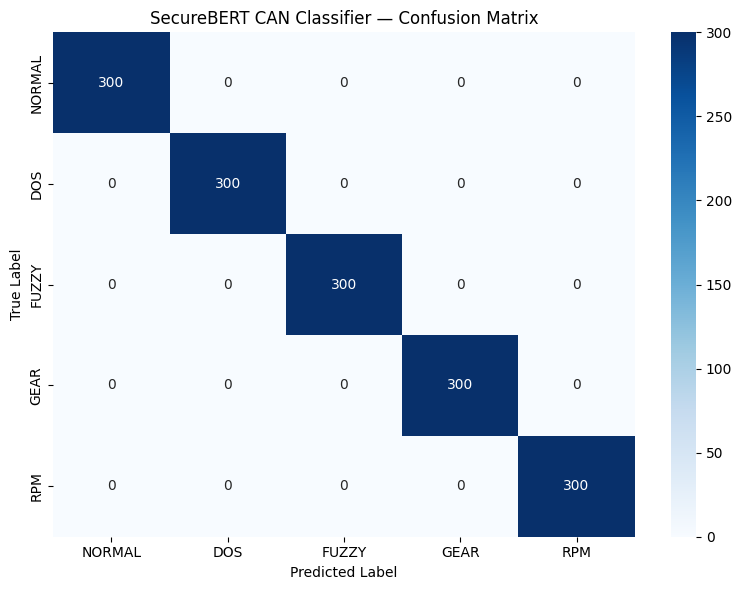

✓ Confusion matrix saved


In [7]:
print("Evaluating on held-out test set...")

predictions = trainer.predict(test_tokenized)
pred_labels = np.argmax(predictions.predictions, axis=-1)
true_labels = test_df["label"].values

print("\nClassification Report:")
print(classification_report(
    true_labels, pred_labels,
    target_names=[LABEL_MAP[i] for i in range(5)]
))

# Confusion matrix
cm = confusion_matrix(true_labels, pred_labels)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=LABEL_MAP.values(),
            yticklabels=LABEL_MAP.values())
plt.title("SecureBERT CAN Classifier — Confusion Matrix")
plt.ylabel("True Label")
plt.xlabel("Predicted Label")
plt.tight_layout()
plt.savefig(str(ARTIFACTS_DIR / "section9a_confusion_matrix.png"), dpi=150)
plt.show()
print(f"✓ Confusion matrix saved")

In [8]:
# Save the fine-tuned model
model_save_path = CHECKPOINTS / "securebert_can_final"
trainer.save_model(str(model_save_path))
tokenizer.save_pretrained(str(model_save_path))
print(f"✓ Model saved to {model_save_path}")

# Extract per-sample confidence scores for test set
import torch.nn.functional as F
logits_tensor = torch.tensor(predictions.predictions)
probs = F.softmax(logits_tensor, dim=-1).numpy()

confidence_df = pd.DataFrame({
    "text":           test_df["text"].values,
    "label":          true_labels,
    "label_name":     [LABEL_MAP[l] for l in true_labels],
    "pred_label":     pred_labels,
    "pred_name":      [LABEL_MAP[l] for l in pred_labels],
    "confidence":     probs.max(axis=1),
    "correct":        (pred_labels == true_labels),
    **{f"prob_{LABEL_MAP[i]}": probs[:, i] for i in range(5)},
    "frames_json":    test_df["frames_json"].values,
    "window_start_ts": test_df["window_start_ts"].values,
})

artifact_path = ARTIFACTS_DIR / "section9a_classifier_results.parquet"
confidence_df.to_parquet(artifact_path, index=False)
print(f"✓ Classifier results saved: {len(confidence_df):,} rows")
print(f"\nAccuracy: {confidence_df['correct'].mean():.3f}")
print(f"Mean confidence (correct):   {confidence_df[confidence_df['correct']]['confidence'].mean():.3f}")
print(f"Mean confidence (incorrect): {confidence_df[~confidence_df['correct']]['confidence'].mean():.3f}")

✓ Model saved to /Users/deepakpatnaik/icidea_llm_ids/checkpoints/securebert_can_final
✓ Classifier results saved: 1,500 rows

Accuracy: 1.000
Mean confidence (correct):   1.000
Mean confidence (incorrect): nan


In [9]:
import pandas as pd
from pathlib import Path

ARTIFACTS_DIR = Path.home() / "icidea_llm_ids" / "artifacts"
df = pd.read_parquet(ARTIFACTS_DIR / "section9b_baseline_explanations.parquet")

print(f"✓ Loaded {len(df)} baseline explanations")
print(f"\nClass distribution:")
print(df["true_label_name"].value_counts().sort_index().to_string())
print(f"\nJSON valid rate: {df['json_valid'].mean()*100:.1f}%")
print(f"Mean inference time: {df['inference_time_s'].mean():.1f}s")
print(f"\nExplanation length stats (characters):")
print(df["qwen_explanation"].str.len().describe().to_string())
print(f"\nSample explanation per class:")
for name in ["NORMAL", "DOS", "FUZZY", "GEAR", "RPM"]:
    row = df[df["true_label_name"] == name].iloc[0]
    print(f"\n  {name}:")
    print(f"    {row['qwen_explanation'][:150]}...")

✓ Loaded 500 baseline explanations

Class distribution:
true_label_name
DOS       100
FUZZY     100
GEAR      100
NORMAL    100
RPM       100

JSON valid rate: 100.0%
Mean inference time: 6.4s

Explanation length stats (characters):
count    500.000000
mean     332.374000
std       68.831109
min      108.000000
25%      280.250000
50%      331.000000
75%      383.500000
max      460.000000

Sample explanation per class:

  NORMAL:
    The CAN bus telemetry sequence shows a steady state with no anomalies or unusual patterns that would suggest a Denial-of-Service (DOS), Fuzzy logic in...

  DOS:
    The sequence consists entirely of identical data packets with no variations or additional information. This behavior is characteristic of a Denial-of-...

  FUZZY:
    The CAN bus telemetry sequence shows a high level of variability and unpredictability in data content and timing. The frequent changes in frame IDs an...

  GEAR:
    The CAN bus telemetry sequence shows a consistent pattern wh